# Introduction

In this tutorial, we will go through the more unique features of the
TurboGAP code that set it apart from other machine-learning interatomic
potential codes/engines: the ability to predict experimental
observables, and infer structures from experimental data via multiple
means.

TurboGAP can give predictions which scale linearly with the number of
atoms for:

1.  X-ray diffraction (XRD)
2.  Neutron diffraction (ND)
3.  Pair Distribution Functions (PDFs) - both standard and corrected by
    atomic form factors/neutron scattering lengths.
4.  X-ray Photoelectron Spectroscopy (XPS)

And we further have aims to extend this to more observables: Raman, IR,
NMR, XAS and TEM just to name a few!

In this tutorial, we will try to be an experimentalist (detective):
given some experimental data, and knowledge of the species proportions
of a measured, can we find out what the structure is?

First, lets see how we can make an experimental observable prediction.

Note on scripts, if you need help, theres helper scripts for all of the
examples, numbered according to the exercises.

# Prediction

Much of the relevant keywords for TurboGAP to predict powder
diffraction-derived quantities (observables 1-3 above) can be found in
`input_files/xrd_options`.

Before looking at it, let’s understand the experimental and
computational context.

A diffraction pattern is a an (averaged) representation of a material’s
reciprocal space. This is why it is useful to identify crystal
structures. For XRD, X-rays undergo diffraction in the material due to
the electron density: different atoms have different electronic
densities, and result in differing intensities. For neutron scattering,
it is due to the atomic nuclei. Bragg’s law,
$n \lambda = 2 d \sin\theta$ the famous rule for constructive
interference, shows that the interplanar spacing (which can be defined
by the change in scattering vector
$\mathbf{q} = \mathbf{K}-\mathbf{K}_0 ,\,\, q =  4\pi \sin \theta / \lambda, \,\, q = 2 \pi / d_{hkl}$).
Hence the proportion of different planes which make up a material (this
is the dual of the atomic, real-space representation of a system), can
be understood and the crystal structure can be deduced. Crystalline
structures exhibit sharp and well-defined peaks, whereas amorphous
systems have diffuse peaks.

The experimental setup is as so: ![hemisphere of diffraction (Wikipedia,
XRD)](attachment:images/Hemisphere_of_Diffraction.png) From the above
image, we can see that a powder xrd pattern (so called powder as powders
are averaged over all orientations). Averaging the measured intensity
over the azimuthal coordinate gives us a 1-d graph of intensity, vs
$q =|\mathbf{q}|$. This is what experimentalists generally obtain.

The Fourier transform of the 1-d XRD/ND powder pattern is the pair
distribution function (modified by scattering factors). Hence, for the
calculation of XRD, we can go from the *pair distribution function* to
the XRD/ND pattern.
$$  g_{ab}(r) =  \frac{n_{ab}(r)}{4\pi r^2\,d r N_a \rho_b } $$

This scales as $\mathcal{O}(N)$ compared to the traditional Debye
equation ($\mathcal{O}(N^2)$). From the above histogram form of the pair
distribution function, we cannot account for thermal/instrumental
broadening of the observable. We can rectify this by doing a kernel
density estimate cannot account for thermal/instrumental broadening of
the observable (the $\sigma$ can be directly related to Debye-Waller
factors).

$$\begin{aligned}
    {\hat{g}_{ab}}(r; \{\mathbf{r}\}) = &\frac{1}{ \sqrt{2\pi}} \frac{V}{4\pi r^2 N_a N_b } \nonumber\\ &\sum_i \sum_{j\neq i} \frac{1}{\sigma_{{ij}}}\exp\left( - \frac{ (r - r_{ij})^2}{2\sigma^2_{ij}}  \right) \delta_{s(i),a}\delta_{s(j),b},
  \end{aligned} $$

We can transform this to the XRD pattern through partial structure
factors. Here, we use the Ashcroft-Langreth formalism $$ \begin{aligned}
S_{ab}(Q)  = &\delta_{ab} + 4\pi \rho (c_{a} c_{b})^{1/2} \\
&\int_0^{r_{\rm cut}} \, \text{d}r \, r^2 \frac{\sin( Q \, r )}{Q \, r} \frac{\sin( \pi \, r / r_{\rm cut} )}{\pi \, r / r_{\rm cut}} [ g_{ab}(r) - 1 ],
\end{aligned} $$ where we have introduced a “window” function
$w(r) = \sin( \pi r / r_{\rm cut} )/(\pi r / r_{\rm cut})$, which
suppresses oscillations in the partial structure factors arising from
the introduction of the cutoff $r_{\rm cut}$.

From the partial structure factors, we can obtain the full intensity by
a summation over system species types: $$ \begin{aligned}
I^{\rm X}(Q) = &\sum_{a,b}^{n_{\rm s}} f_{a}(Q) f_{b}(Q) (c_{a}c_{b})^{1/2}  \left[ S_{a b}(Q) - \delta_{a b}\right] \nonumber\\ &+ \sum_{a}^{n_{\rm s}} c_{a}f_{a}(Q)^2.
\end{aligned} $$

Hence, there are a number of parameters which are needed for the
calculation!

<!-- Partial structure factors are:  -->
<!-- $$  \begin{aligned} -->
<!--     \frac{\partial}{\partial r_{k}^{\alpha}} {\hat{S}_{ab}}(Q; \{\mathbf{r}\}) &=  4\pi \rho (c_{a} c_{b})^{1/2} \nonumber\\ &\int^{r_{\rm cut}}_0 \,d r   \left( r^2\frac{\sin( Q r )}{Qr} \frac{\sin( \pi r / r_{\rm cut} )}{\pi r / r_{\rm cut}}  \frac{\partial {\hat{g}_{ab}}(r; \{\mathbf{r}\})}{\partial r^{\alpha}_k}  \right). -->
<!--   \end{aligned} $$ -->
<!--   Modify these by the scattering factors to get the XRD/ND gradients. -->
<!--   \begin{equation} -->
<!--     \frac{\partial I^{\rm X}(Q; \{\mathbf{r}\})}{\partial r^{\alpha}_k} = \sum_{a b}^{n_{\rm s}} f_{a}(Q) f_{b}(Q) (c_{a}c_{b})^{1/2}  \frac{\partial \textcolor{ForestGreen}{\hat{S}_{a b}}(Q; \{\mathbf{r}\})}{\partial r^{\alpha}_k}, -->
<!--   \end{equation} -->
<!--   Finally obtain the forces to match experiment. -->
<!--   \begin{equation} -->
<!--     \tilde{f}_k^{\alpha} = - \frac{\partial -->
<!--       V^{\rm X}}{\partial r^{\alpha}_k}  =  - \gamma \mathbf{w}\odot\frac{\partial -->
<!--       \mathbf{I}^{\rm X}_{\rm pred}}{\partial r^{\alpha}_k} \cdot \left( \mathbf{w}\odot \left( -->
<!--         \mathbf{I}^{\rm X}_{\rm {pred}} - \mathbf{I}^{\rm X}_{\rm {exp}} \right) \right). -->
<!--   \end{equation} -->

``` config
                                         # --- PDF parameters ---
                                         # ----------------------
do_pair_distribution        = .true.     # Calculate the XRD from the pair distribution 
                                         # function, so it scales linearly with the number of atoms
pair_distribution_kde_sigma =   0.1      # -> Use Gaussian Kernel Density Estimate of 
                                         #    width 0.1A to smooth out, accounting for thermal
                                         #    broadening
pair_distribution_n_samples =  201       # -> Number of samples used for pdf. 
pair_distribution_partial   = .true.     # -> Calculate partial pair-distribution functions
pair_distribution_rcut      =  10.6      # -> Cutoff partial pair distribution 
r_range_min                 =   0.1      # -> Range for the PDF calculation   
r_range_max                 =  10.0      # -> Range - " - 
write_pair_distribution     = .true.     # -> Write out pair distribution functions 


                                         # --- SF parameters ---
                                         # ---------------------
do_structure_factor         = .true.     # Use (raw, non-scattering factor corrected) 
                                         # (partial) structure factor(s) for calculations 
structure_factor_from_pdf   = .true.     # -> Fourier transform the pair distribution functions 
                                         #    to obtain the uncorrected structure factors, which
                                         #    when corrected give the XRD pattern. 
structure_factor_window     = .true.     # -> Use a multiplicative "windowing" function 
                                         #    (sin(pi r / r_cut)/(pi r / r_cut)) in the fourier 
                                         #    transform of pdf to minimize high frequency 
                                         #    artifacts resulting from the finite range.
write_structure_factor      = .true.     # -> Write out structure factors


                                         # --- X-ray parameters ---
                                         # --- (swap 'xrd' with 'nd' in keywords for neutron diffraction)
                                         # ------------------------
do_xrd                      = .true.     # Do X-Ray diffraction prediction 
q_range_min                 =   0.1      # -> Range for the XRD/structure factor calculation:
                                         #    q = 4 pi sin( theta ) / lambda, where theta is 
                                         #    the half angle of diffraction
q_range_max                 =  10.0      # -> - " - 
xrd_n_samples               =  101       # -> Number of samples for the xrd pattern, if 
                                         #    experimental data is provided, this is overriden 
                                         #    by the exp_n_samples
write_xrd                   = .true.     # -> Write out xrd pattern
xrd_output                  = 'q*F(q)'   # -> Output the XRD pattern as the direct Fourier 
                                         #    transform of G(r), the reduced PDF (this can be 
                                         #    'F(q)'/'i(q)' or the full xrd intensity 'xrd')
```

As can be seen in the `input_files/xrd_options`

Similarly, one can do this for XPS, if there is an appropriate local
property model which is specified in the .gap file.

``` conf
do_xps           = .true.
xps_e_min        =   280
xps_e_max        =   300
xps_n_samples    =   301
```

## Exercise 1.

Here, we will just get used to using the prediction keywords.

First, lets do a simple simulation where destroy some graphite with
oxygen.

We can first run the python script in the terminal to make a .xyz file
where we have randomly inserted oxygens into a graphite structure.
`python scripts/make_graphite_O.py`

Now, lets see what happens to the XRD pattern as we melt this structure.

Create an input file which does high-temperature MD to melt this
structure, which also shows the XRD pattern.

If you’re struggling, you can use the input file which is provided in
the input files section `input_files/input_melt_graphite_CO`

Now lets have a look at what is going on with the observables. How does
the XRD change from the initial unmelted structure to the final one?
What about the XPS?

In [1]:
# Module imports
from ase.io import read # Used to generate an ASE Atoms object from various XYZ files
from weas_widget import WeasWidget # The visualization widget to take a look at the structures
import numpy as np # Numpy is always useful
import matplotlib as mpl # For plots
import matplotlib.pyplot as plt # For plots
import copy


In [32]:
def display( atoms ):
    viewer = WeasWidget()
    viewer.avr.model_style = 1 # ball & stick mode
    viewer.from_ase(atoms)
    viewer.avr.show_bonded_atoms = True # show bonds across periodic boundaries
    return viewer

def get_data_from_file( filename ):
    all_data = []
    with open( filename, 'r' ) as f:
        # First line is always a comment, so we ignore
        f.readline()
        # usually the format is in x, y, (weight - optional)
  
        line = f.readline()
        data = np.array([ float( s ) for s in line.split() ])
        line = f.readline()
        while ( len( line.split() ) > 0 ):
            new_data = np.array([ float( s ) for s in line.split() ])
            data = np.vstack( (data, new_data) )
            line = f.readline()
            if (len( line.split() ) == 0 ): 
                all_data.append( data)
                line = f.readline()
                data = np.array([ float( s ) for s in line.split() ])
    return all_data

def plot_data( ax, data_rmc, data_exp, colormap=plt.cm.viridis, log_colors=False):
    N = len(data_rmc)
    if not log_colors:
        colors = colormap(np.linspace(0,1,N))
    else:
        colors = colormap(1.-np.logspace(0,-1,N, endpoint=True) + np.linspace(0,0.1,N) )
        
    for i, d in enumerate(data_rmc):
        alpha = np.log( 1 + (i+1)/N ) / np.log(2)
        if ( i + 1 == N ):
            label="Prediction"
        else:
            label = ""
        if ( len(data_rmc) == 2):
            if ( i == 0 ):
                label = "initial pred."
            if i == 1:
                label = "final pred."
        ax.plot( d[:,0], d[:,1], color = colors[i], alpha = alpha, label=label  )
    if not data_exp is None:
        ax.plot(data_exp[:,0], data_exp[:,1], 'k--', label='Exp.')

def plot_xps( ax, data_rmc, data_exp, colormap=plt.cm.viridis, log_colors=False):
    ax.set_xlim(282, 292)
    ax.set_title("XPS")
    ax.set_ylabel( "Intensity" ) 
    ax.set_xlabel( "Core-electron binding energy [eV]" ) 
    plot_data(ax, data_rmc, data_exp, colormap=colormap, log_colors=log_colors)
    ax.legend()

def plot_xrd( ax, data_rmc, data_exp, colormap=plt.cm.viridis, log_colors=False):
    # ax.set_xlim(0, )
    ax.set_title("XRD")
    ax.set_ylabel( "Intensity (q*F(q))" ) 
    ax.set_xlabel( "q [1/A]" ) 
    plot_data(ax, data_rmc, data_exp, colormap=colormap, log_colors=log_colors)
    ax.legend()
    
def plot_pdf( ax, data_rmc, data_exp, colormap=plt.cm.viridis, log_colors=False):
    # ax.set_xlim(282, 292)
    ax.set_title("PDF")
    ax.set_ylabel( "Intensity" ) 
    ax.set_xlabel( "r [A]" ) 
    plot_data(ax, data_rmc, data_exp, colormap=colormap, log_colors=log_colors)
    ax.legend()
    


In [6]:
# Show results of the melting
atoms = read("1.melt/trajectory_out.xyz", index = ':')
display( atoms ) 

WeasWidget(children=(<weas_widget.base_widget.BaseWidget object at 0x7f7eed691410>,))

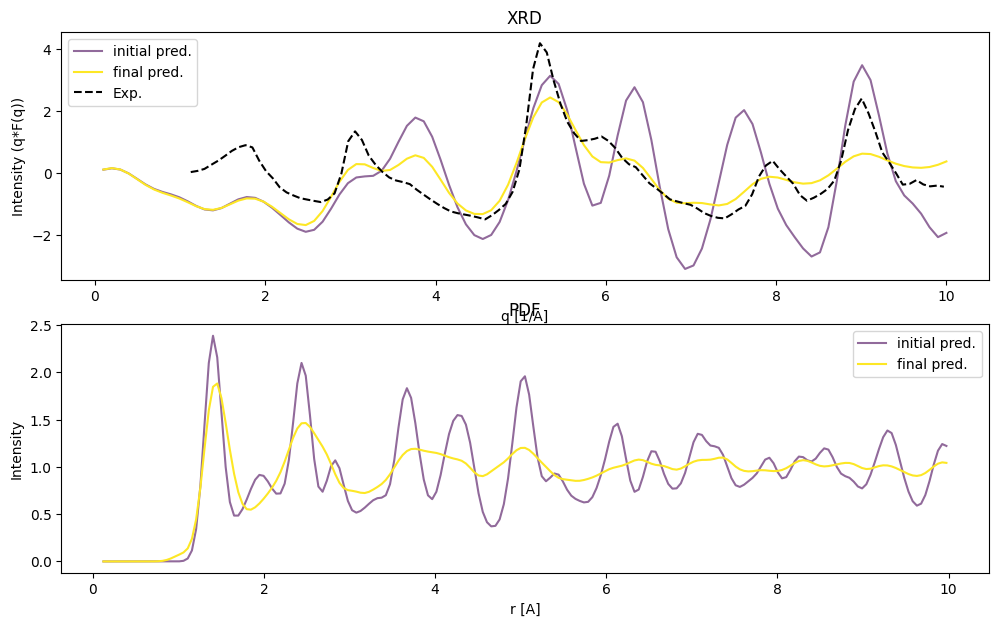

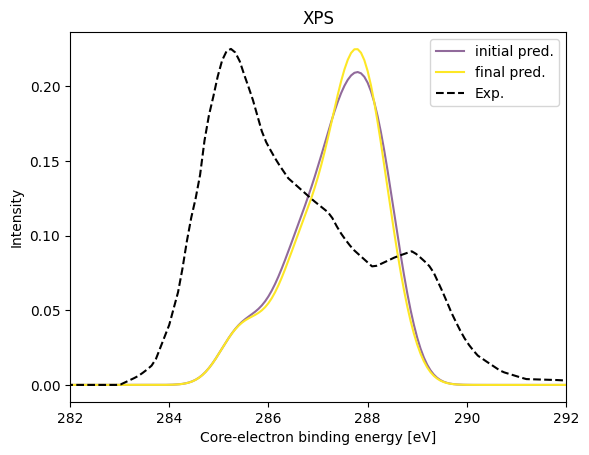

In [35]:
fig, axs = plt.subplots(2, 1, figsize=(10,6))
fig.tight_layout()
fig2 = plt.figure()
ax = fig2.add_subplot(111)

data_xps     = get_data_from_file( '1.melt/xps_prediction.dat' ) 
# Limiting data to the initial and final configurations only
data_xps = [ data_xps[0], data_xps[1] ]
data_xps_exp = get_data_from_file( 'data/xps_spectra_interp.dat' )[0]

data_xrd     = get_data_from_file( '1.melt/xrd_prediction.dat' ) 
data_xrd = [ data_xrd[0], data_xrd[1] ]
data_xrd_exp = get_data_from_file( 'data/xrd_glassy_carbon_zeng_2017.fq' )[0]

data_pdf     = get_data_from_file( '1.melt/pair_distribution_total.dat' ) 
data_pdf = [ data_pdf[0], data_pdf[1] ]
data_pdf_exp = None

plot_xps( ax    , data_xps, data_xps_exp) 
plot_xrd( axs[0], data_xrd, data_xrd_exp) 
plot_pdf( axs[1], data_pdf, data_pdf_exp) 

plt.show()

# Structural Inference

## Reverse Monte-Carlo

As seen in our paper *Experiment-Driven Atomistic Materials Modeling: A
Case Study Combining X-Ray Photoelectron Spectroscopy and Machine
Learning Potentials to Infer the Structure of Oxygen-Rich Amorphous
Carbon* <https://pubs.acs.org/doi/full/10.1021/jacs.4c01897>

We can create an XPS-optimized structure by modifying the total energy
of the system $E_{\rm total}$ with a pseudoenergy term $E_{\rm spectra}$
which reflects how well our predicted spectra
$h_{\rm pred}(E, \{\mathbf{r}\})$ agrees with an experimental spectra
$h_{\rm exp}(E)$, where here $E$ corresponds to the core-electron
binding energy scale. $$ \tilde{E} = E_{\rm total} + E_{\rm spectra} $$

We define
$$ E_{\rm spectra} = \frac{1}{2} \gamma \left( \mathbf{h}_{\rm pred} - \mathbf{h}_{\rm pred} \right)^2$$
where the bold font shows that we have represented the spectrum as a
vector, with samples $[\mathbf{h}]_i$ at $[\mathbf{E}]_i$.

We can use this energy Grand-Canonical Monte-Carlo simulations to create
structures which agree with experimental XPS data by design.

### What is XPS?

XPS is a characterization method which allows for atomic environments to
be distinguished. The primary measured quantity are core-electron
binding energies, which are obtained by firing an X-ray at the sample, a
core electron being ejected, and it’s kinetic energy measured (where the
difference in incident photon energy and the kinetic energy gives the
core-electron binding energy). Core-electron binding energies are
primarily dependent on their *local environment*. Different motifs
exhibit different core-electron binding energies.

Therefore, given a spectrum of core-electron binding energies from a
sample, and assuming locality, experimentalists can deconvolve this
spectrum into contributions from different motifs by trying to fit this
spectrum using reference databases of core-electron binding energies.
This gives the relative proportions of % motifs in their samples.

An XPS model can be made if this environmental sensitivity of the core
electron can be sufficiently described. Simple analytical models for
such a dependence do not exist due to the quantum-mechanical nature of
the problem. However, we can use the flexibility of kernel ridge
regression to furnish us with a forward model for XPS prediction using
ab-initio reference data. We use the core-electron binding energy models
of Golze 2022 (https://doi.org/10.1021/acs.chemmater.1c04279), trained
on DFT and $GW$ calculations.

XPS spectrum predictions
$\tilde{I}^{\rm XPS} \left( \varepsilon ; \left\{\mathbf{r}\right\}\right)$
are obtained from core-electron binding energies
$\varepsilon^i_{\rm pred} =
\varepsilon^i_{\rm pred}\left(\mathbf{q}^i(\left\{ \mathbf{r} \right\})\right)$,
where $i$ is the index of an atom and $\mathbf{q}^i$ is the many-body
descriptor of the $i$th atom’s local environment (SOAP turbo
descriptors). To account for thermal and experimental broadening, one
can smear out these core-electron binding energies by a Gaussian,
resulting in the following expression for the XPS spectrum: $$
     \tilde{I}^{\rm XPS}(\varepsilon; \{\mathbf{r}\})  = \sum_{i} \exp\left(
-\frac{\left(\varepsilon - \varepsilon^{i}_{\rm {pred}}\right)^2}{2\sigma_{\rm xps}^2}\right).
$$

<!-- Such a model provides an example of an observable which depends on predicted local quantities, in this case $\varepsilon^i_{\rm pred}(\mathbf{q}^i(\{\mathbf{r}\})$, which cannot be expressed as simple functions of atomic positions.  -->
<!-- % In particular, $\varepsilon^{i}_{\rm pred}$ in Ref.~\cite{golze_2022} uses a kernel ridge regression \gls{ML} approach trained from \textit{ab-initio} reference data~\cite{klawohn_2023}.  -->
<!-- The critical point to note is that this formulation accepts analytical gradients of the local property.  -->
<!-- Taking the derivative, and exploiting the differentiable nature of atomic descriptors, we obtain: -->
<!-- \begin{align}\label{eq:xps_forces} -->
<!--  &\frac{\partial \tilde{I}^{\rm XPS}(\varepsilon; \{\mathbf{r}\})}{\partial -->
<!-- r^{\alpha}_k} = \nonumber\\ -->
<!-- &\sum_{i} \frac{(\varepsilon - \varepsilon^{i}_{\rm pred})}{\sigma_{\rm xps}^2} -->
<!-- \frac{\partial \varepsilon^{i}_{\rm pred}}{\partial r^{\alpha}_k} -->
<!--  \exp\left( -->
<!-- -\frac{(\varepsilon - \varepsilon^{i}_{\rm {pred}})^2}{2\sigma_{\rm xps}^2}\right), -->
<!-- \end{align} -->
<!-- where, -->
<!-- \begin{equation} -->
<!-- \frac{\partial \varepsilon^{i}_{\rm pred}\left(  \mathbf{q}^i\left( \left\{ \mathbf{r}\right\} \right) \right) }{\partial r^{\alpha}_k} =  \nabla_{\mathbf{q}^i} \varepsilon^{i}_{\rm pred} \cdot \frac{\partial   \mathbf{q}^i\left( \left\{ \mathbf{r}\right\} \right)  }{\partial r^{\alpha}_k}. -->
<!-- \end{equation} -->
<!-- In the case of the model from Ref.~\cite{golze_2022}, $\varepsilon^{i}_{\rm pred}$ is given as a linear -->
<!-- combination of dot-product kernels: -->
<!-- \begin{equation} -->
<!-- \varepsilon^{i}_{\rm pred} (\mathbf{q}^i(\{\mathbf{r}\})) = \varepsilon_0 +  \delta_s^2 \sum_s \alpha_s \left( \mathbf{q}^i \cdot -->
<!-- \mathbf{q}^s \right)^\zeta, -->
<!-- \end{equation} -->

### Invoking XPS optimization in Turbogap

We simply add this to the input file

``` config
# Experimental Data Specification
n_exp = 1                                     # Number of experimental observables we wish 
                                              # the structure to replicate
exp_labels = 'xps'                            # Labels of experimental observables 
                                              # (currently limited to xps/xrd/nd/pdf)
exp_data_files = 'xps_spectra_interp.dat'     # Experimental data
exp_n_samples = 501                           # Number of samples for linear interpolation 
                                              # of experimental data (needed if data is not on 
                                              # a uniform grid), this number should be greater 
                                              # than the number of data points in the experimental file.
exp_energy_scales = 10.0                      # The energy scale "gamma" as above
```

If experimental data is added, and it is possible to calculate the
observable, **TurboGAP** by default will calculate the $E_{\rm spectra}$
term and add it to the total energy.

To turn this off, we can set \`exp<sub>energies</sub> = .false.\`

We can also do reverse monte-carlo using multiple types of experimental
data, such as with this arbitrary example.

``` config
n_exp = 2                                              
exp_labels = 'xps' 'xrd'                               
exp_data_files = 'xps_spectra_interp.dat' 'xrd_CO.dat' 
exp_n_samples = 501 201                                
exp_energy_scales = 10.0 100.0                         
```

### Exercise 2.

Do some reverse monte-carlo simulation using `turbogap mc` from the
melted structure and pretend you don’t know where the XPS data we are
using came from. How different is the XPS data from the initial
graphite-oxygen structure to this?

We don’t have enough time to really optimize the structure, but, one is
really able to find suitable structures which are both low in energy on
the potential energy surface, yet agree with experimental data. From the
MD example earlier, we can see there is a proclivity for CO/CO_2 to form
when doing high temperature annealing. This state-of-the-art protocol
for generating metastable structures does not work for oxygenated
amorphous carbon. Hence using Reverse Monte-Carlo is a feasible means
for generating such structures, inhibiting features which are not seen
in experiment.

One further thing to note is the fact that such a method allows for
direct interpretation of experimental data. The interpretation of XPS
spectra is a problem fraught with difficulties for experimentalists.
Using atomistic models, we can directly deconvolve the XPS spectra into
its constitutent parts using such optimization

<figure>
<img src="attachment:images/deconvolution_comparison_fill_justhigh.png"
alt="XPS deconvolution" />
<figcaption aria-hidden="true">XPS deconvolution</figcaption>
</figure>

In [11]:
# Reverse Monte-Carlo
display( read("2.reverse_mc/mc_all.xyz", index = ':') )

WeasWidget(children=(<weas_widget.base_widget.BaseWidget object at 0x7f7ee64fac90>,))

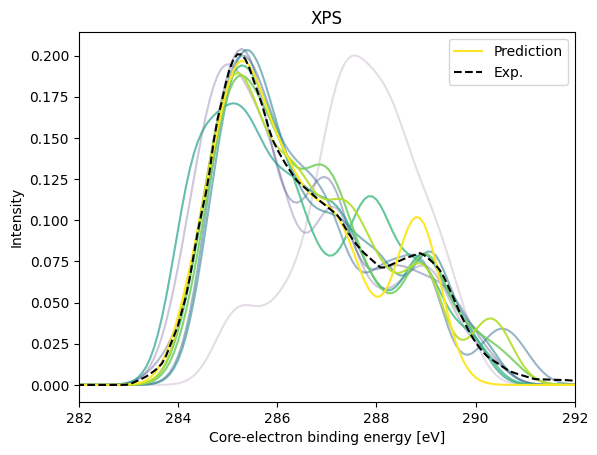

In [44]:
def choose_n_configs( N, data ):
    if ( len(data) < N ):
        return data
    if N == 1:
        return [ data[0]]
    if N == 2:
        return [ data[0], data[-1] ]
    indices =  [ int(i) for i in np.linspace( 0, len(data), N, endpoint=False) ]
    return [ data[i] for i in indices ] 

# fig, axs = plt.subplots(2, 1, figsize=(10,6))
# fig.tight_layout()
fig2 = plt.figure()
ax = fig2.add_subplot(111)

n = 10
data_xps     = get_data_from_file( '2.reverse_mc/xps_prediction.dat' ) 
# Limiting data to the initial and final configurations only
data_xps = choose_n_configs( n, data_xps ) 
data_xps_exp = get_data_from_file( '2.reverse_mc/xps_exp.dat' )[0]

# data_xrd     = get_data_from_file( '2.reverse_mc/xrd_prediction.dat' ) 
# data_xrd = choose_n_configs( n, data_xrd )
# data_xrd_exp = get_data_from_file( 'data/xrd_glassy_carbon_zeng_2017.fq' )[0]

# data_pdf     = get_data_from_file( '2.reverse_mc/pair_distribution_total.dat' ) 
# data_pdf = choose_n_configs( n, data_pdf)
# data_pdf = [ data_pdf[0], data_pdf[1] ]
# data_pdf_exp = None

plot_xps( ax    , data_xps, data_xps_exp) 
# plot_xrd( axs[0], data_xrd, data_xrd_exp) 
# plot_pdf( axs[1], data_pdf, data_pdf_exp) 

plt.show()

## Molecular Augmented Dynamics

Reverse Monte-Carlo is very useful for being able to sample complex
observables, where derivatives with respect to the atomic position are
lacking, however, it is prone to being stuck in minima. In general the
acceptance criterion for a monte-carlo move is
$\alpha \propto \exp (-\Delta E)$. Hence, when there are stable motifs
found in the structure, it is very hard for the whole system to move out
of them, with many trial configurations being rejected, which reduces
efficiency.

Molecular dynamics, on the other hand, is efficient: every evaluation
the energy and forces will be put to good use. This does however mean
that one must implements gradients of the experimental potential, which
is a pain. However, I have gone through that pain for you.

This means that we can greatly scale our simulations from before. As
shown in our preprints (https://arxiv.org/abs/2508.17132, and
https://arxiv.org/abs/2509.22388) we can go up multiple orders of
magnitude in terms of system size due to this.

$$\begin{aligned}
    V_{\rm total}           &= V_{\rm GAP} + \tilde{V}_{\rm exp} \\
    \tilde{V}_{\rm exp}     &=  \frac{1}{2} \gamma \left( \mathbf{w} \odot \left(\mathbf{I}_{\rm {pred}}( \{\mathbf{r}\} ) - \mathbf{I}_{\rm {exp}}\right)\right)^2 \\
    \tilde{f}_{ k}^{\alpha} &= -\frac{\partial \tilde{V}_{{\mathrm{exp}}}}{\partial r^{\alpha}_k} \\
                            &=   - \gamma \mathbf{w} \odot \frac{\partial \mathbf{I}_{\rm pred}(\left\{ \mathbf{r}\right\})}{\partial r^{\alpha}_k} \cdot \mathbf{w} \odot \left(\mathbf{I}_{\rm {pred}}(\left\{ \mathbf{r}\right\}) - \mathbf{I}_{\rm {exp}} \right).
\end{aligned}$$

$$  \begin{aligned}
    \frac{\partial}{\partial r_{k}^{\alpha}} {\hat{S}_{ab}}(Q; \{\mathbf{r}\}) &=  4\pi \rho (c_{a} c_{b})^{1/2} \nonumber\\ &\int^{r_{\rm cut}}_0 \,d r   \left( r^2\frac{\sin( Q r )}{Qr} \frac{\sin( \pi r / r_{\rm cut} )}{\pi r / r_{\rm cut}}  \frac{\partial {\hat{g}_{ab}}(r; \{\mathbf{r}\})}{\partial r^{\alpha}_k}  \right).
  \end{aligned} $$

Modify these by the scattering factors to get the XRD/ND gradients.
$$    \frac{\partial I^{\rm X}(Q; \{\mathbf{r}\})}{\partial r^{\alpha}_k} = \sum_{a b}^{n_{\rm s}} f_{a}(Q) f_{b}(Q) (c_{a}c_{b})^{1/2}  \frac{\partial {\hat{S}_{a b}}(Q; \{\mathbf{r}\})}{\partial r^{\alpha}_k},
$$

Finally obtain the forces to match experiment. $$
    \tilde{f}_k^{\alpha} = - \frac{\partial
      V^{\rm X}}{\partial r^{\alpha}_k}  =  - \gamma \mathbf{w}\odot\frac{\partial
      \mathbf{I}^{\rm X}_{\rm pred}}{\partial r^{\alpha}_k} \cdot \left( \mathbf{w}\odot \left(
        \mathbf{I}^{\rm X}_{\rm {pred}} - \mathbf{I}^{\rm X}_{\rm {exp}} \right) \right).
$$

For doing MAD simulations, all of the above is similar, except that we
are doing molecular dynamics! To turn on MAD forces we use the keyword
`exp_forces = .true.` after the specification of fitting to experiment,
the keywords in the reverse monte-carlo section. MAD will work only when
there is a valid set of experimental data and a means for a forward
experimental prediction.

``` config
# Experimental Data Specification
n_exp = 1                                     # Number of experimental observables we wish 
                                              # the structure to replicate
exp_labels = 'xps'                            # Labels of experimental observables 
                                              # (currently limited to xps/xrd/nd/pdf)
exp_data_files = 'xps_spectra_interp.dat'     # Experimental data
exp_n_samples = 501                           # Number of samples for linear interpolation 
                                              # of experimental data (needed if data is not on 
                                              # a uniform grid), this number should be greater 
                                              # than the number of data points in the experimental file.
exp_energy_scales = 10.0                      # The energy scale "gamma" as above

exp_energies = .true.
exp_forces   = .true.
```

In [17]:
# Reverse Monte-Carlo
display( read("3.mad/trajectory_out.xyz", index = ':') )

WeasWidget(children=(<weas_widget.base_widget.BaseWidget object at 0x7f7ee2c65c90>,))

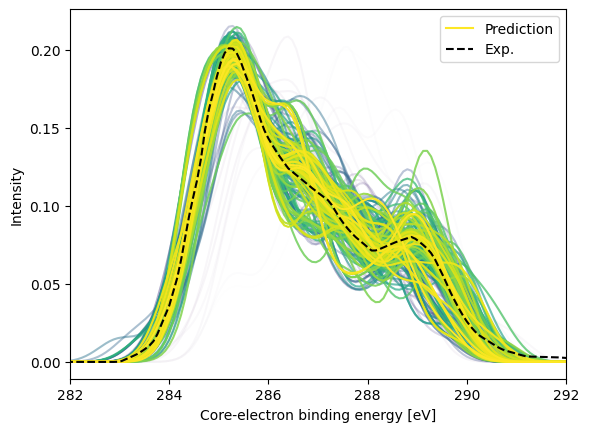

In [16]:

filename = '3.reve/xps_prediction.dat'
data_rmc = get_data_from_file( filename ) 

filename = '2.reverse_mc/xps_exp.dat'
data_exp = get_data_from_file( filename )[0]

fig = plt.figure()
ax = fig.add_subplot( 111 )

plot_xps( ax, data_rmc, data_exp) 

plt.show()

## Exercise 3.

If time permits, do a MAD simulation which tries to fit the XPS data
from the melted graphite O structure.

## General considerations when using experimental estimations

One must be aware of the possible pitfalls when using what’s called a
“forward” model for prediction: *i.e., going from an atomic structure to
an observable*. Observations gathered from an experiment are usually
assumed to be at thermodynamic equilibrium, which means that the typical
ensemble statistics hold: \_i.e. using configurations sampled from the
thermodynamic partition function of choice, we can obtain a reasonable
estimate of an observable.\_Much of the time in our simulations, we wish
to assume that our simulation cell is close enough to the real system,
which allows one to forgo the need for multiple configurations from an
ensemble. Care must be taken when considering systems undergoing
transitions as typically the number of configurations needed can
drastically change, especially if the transition is disordered.